---

# 📘 **Module 3: Time Series Forecasting – Full Lecture Notes**

---

## 🧩 **1. Introduction to Time Series Forecasting**

### 1.1 What is a Time Series?

A *time series* is an ordered sequence of observations ( y_t ) collected over time.
Examples: daily sales, hourly temperature, monthly revenue, etc.

Key characteristics:

* **Trend** – long-term increase/decrease.
* **Seasonality** – repeating short-term cycle (e.g., daily, weekly, yearly).
* **Noise / Irregularity** – random variations.
* **Stationarity** – statistical properties (mean, variance, autocovariance) constant over time.

---

## 🧠 **2. Classical Forecasting Methods**

---

### 2.1 ARIMA / SARIMAX Models

#### (A) Concept & Intuition

ARIMA = **Auto-Regressive Integrated Moving Average**
[
y_t = c + \phi_1 y_{t-1} + ... + \phi_p y_{t-p}
+ \theta_1 \varepsilon_{t-1} + ... + \theta_q \varepsilon_{t-q}
+ \varepsilon_t
]

* (p) = AR order (lags of (y))
* (d) = order of differencing (to remove trend)
* (q) = MA order (lags of errors)

SARIMAX extends ARIMA with:

* Seasonal terms ((P, D, Q, s))
* Exogenous variables (X_t) (hence the “X”).

---

#### (B) Workflow

1. Plot the series → visualize trend/seasonality.
2. Test stationarity (ADF, KPSS).
3. Use ACF & PACF plots to guess p/q.
4. Fit ARIMA or SARIMAX.
5. Diagnose residuals → white-noise?
6. Forecast → mean + confidence interval.

---

#### (C) Code Example – SARIMAX


In [4]:
import sys, importlib, inspect
print("python exe:", sys.executable)
import scipy, statsmodels
print("scipy:", scipy.__version__, "location:", scipy.__file__)
print("statsmodels:", statsmodels.__version__, "location:", statsmodels.__file__)

python exe: C:\Users\Public\anaconda3_1\envs\pymc_env\python.exe
scipy: 1.16.3 location: C:\Users\Public\anaconda3_1\envs\pymc_env\Lib\site-packages\scipy\__init__.py
statsmodels: 0.14.6 location: C:\Users\Public\anaconda3_1\envs\pymc_env\Lib\site-packages\statsmodels\__init__.py


In [ ]:
!pip install statsmodels

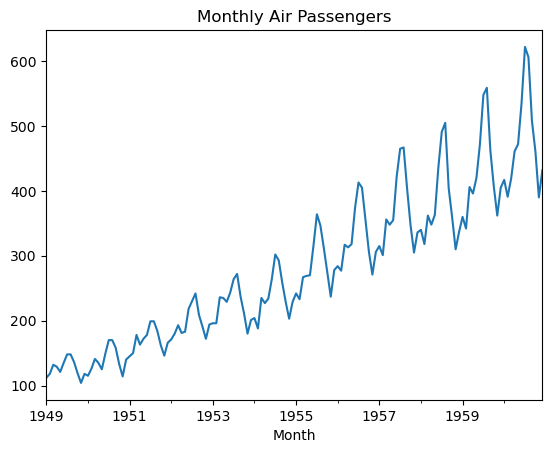

C:\Users\Public\anaconda3_1\envs\pymc_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Public\anaconda3_1\envs\pymc_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Fri, 12 Dec 2025   AIC                           1022.299
Time:                                    05:06:26   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1273      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

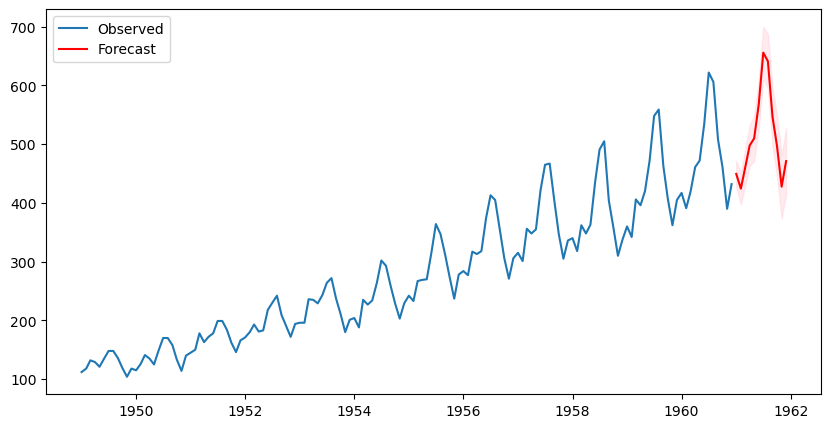

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Load example series (AirPassengers)
y = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv",
    parse_dates=['Month'], index_col='Month'
).squeeze()

y.plot(title="Monthly Air Passengers"); plt.show()

# 2. Fit SARIMAX(1,1,1)(1,1,1,12)
model = SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12))
res = model.fit(disp=False)
print(res.summary())

# 3. Forecast next 12 months
pred = res.get_forecast(steps=12)
mean_forecast = pred.predicted_mean
ci = pred.conf_int()

plt.figure(figsize=(10,5))
plt.plot(y, label='Observed')
plt.plot(mean_forecast, label='Forecast', color='r')
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='pink', alpha=0.3)
plt.legend(); plt.show()


##### 👉 Explanation:

* `SARIMAX(y, order=(1,1,1), seasonal_order=(1,1,1,12))`
  defines the model: first-order AR & MA, first differencing, yearly seasonality (12 months).
* `fit()` estimates coefficients via MLE.
* `get_forecast(steps=12)` generates predictions and 95% intervals.
* The shaded area = uncertainty interval; the wider the band, the higher uncertainty.

---

### 2.2 Exponential Smoothing (Holt-Winters)

#### Concept

Weighted average where recent observations receive more weight.

* *Simple ES* – no trend/seasonality.
* *Holt’s linear trend* – adds trend component.
* *Holt-Winters* – adds seasonal component.

#### Code


C:\Users\Public\anaconda3_1\envs\pymc_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


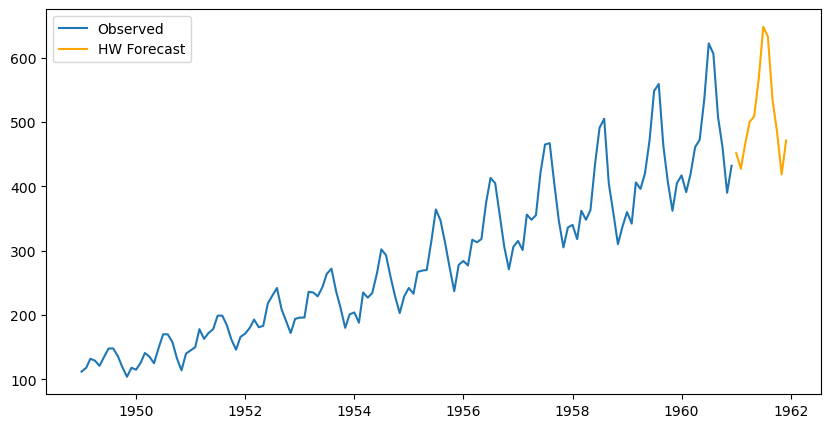

In [8]:

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw.fit()
forecast = hw_fit.forecast(12)

plt.figure(figsize=(10,5))
plt.plot(y, label='Observed')
plt.plot(forecast, label='HW Forecast', color='orange')
plt.legend(); plt.show()


##### Explanation:

* `trend='add'` → additive trend component.
* `seasonal='add'` → additive seasonal pattern.
* Holt-Winters is fast and interpretable; useful for smooth demand patterns.

---

### 2.3 Facebook Prophet

#### Concept

Decomposes time series into:
[
y(t) = g(t) + s(t) + h(t) + \varepsilon_t
]

* (g(t)) = piecewise-linear/logistic trend
* (s(t)) = seasonal components
* (h(t)) = holiday effects
* Automatic changepoint detection.

#### Code


In [10]:
!pip install Prophet

  Using cached prophet-1.2.1-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.2.1-py3-none-win_amd64.whl (12.1 MB)
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.3 MB/s  0:00:00
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/5 [tqdm]
   ---------------------------------------- 0/5 [tqdm]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------



##### Explanation:

* `add_country_holidays('US')` adds known holidays.
* `changepoint_prior_scale` controls flexibility (higher → more responsive to trend changes).
* `plot_components()` shows decomposed trend, seasonality, and holiday effects.

---

## ⚙️ **3. Advanced Techniques**

---

### 3.1 Deep Learning for Time Series (LSTM / GRU)

#### Concept

Neural nets for sequences; capture long-term dependencies via gating mechanisms.
Input = sequence of past n timesteps, output = next step(s).

#### Steps

1. Normalize the data.
2. Create sliding windows (X,y).
3. Build an LSTM or GRU network.
4. Train → validate → forecast.

#### Code (TensorFlow Keras)


In [19]:

import numpy as np, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# Prepare windowed dataset
data = y.values.reshape(-1,1)
scaler = MinMaxScaler(); data_scaled = scaler.fit_transform(data)
window = 12
X, Y = [], []
for i in range(len(data_scaled)-window):
    X.append(data_scaled[i:i+window])
    Y.append(data_scaled[i+window])
X, Y = np.array(X), np.array(Y)

# Split train/test
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# Build LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window,1)),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, Y_train, epochs=30, batch_size=16,
                    validation_split=0.1, verbose=1)

# Forecast next 12 points
last_window = X_test[-1].reshape(1,window,1)
preds = []
for _ in range(12):
    next_val = model.predict(last_window)
    preds.append(next_val[0,0])
    last_window = np.append(last_window[:,1:,:], [[next_val]], axis=1)

forecast = scaler.inverse_transform(np.array(preds).reshape(-1,1))


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0570 - val_loss: 0.0925
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0162 - val_loss: 0.0173
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0106 - val_loss: 0.0197
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0092 - val_loss: 0.0192
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0070 - val_loss: 0.0233
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0071 - val_loss: 0.0204
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0065 - val_loss: 0.0176
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0059 - val_loss: 0.0178
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0059 - val_loss: 0.0176
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0055 - val_loss: 0.0181
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0054 - val_loss: 0.0189
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0052 - val_loss: 0.0181


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 4 dimension(s)


##### Explanation:

* `MinMaxScaler` ensures faster training (values in [0,1]).
* `window` = number of look-back steps.
* Each loop iteration predicts one step ahead and rolls window forward.
* Model learns temporal dependencies automatically (no manual lag features).

---

### 3.2 Using Darts Library – Unified API

Darts provides one interface for classical, DL, and probabilistic models.



In [22]:

from darts import TimeSeries
from darts.models import ExponentialSmoothing, RNNModel
from darts.metrics import mae

series = TimeSeries.from_series(y)
train, val = series.split_after(0.8)

# Classical
hw_model = ExponentialSmoothing()
hw_model.fit(train)
pred_hw = hw_model.predict(len(val))

# Deep Learning
rnn = RNNModel(model='LSTM', input_chunk_length=12, output_chunk_length=6,
               n_epochs=50, random_state=42)
rnn.fit(train)
pred_rnn = rnn.predict(len(val))

print("HW MAE:", mae(val, pred_hw))
print("RNN MAE:", mae(val, pred_rnn))

ModuleNotFoundError: No module named 'darts'


##### Explanation:

* `input_chunk_length` = window size, `output_chunk_length` = forecast horizon.
* `fit()` and `predict()` behave consistently for all models.

---

### 3.3 Probabilistic Forecasting & Monte Carlo

#### Idea

Forecast not just a point, but a *distribution*.

Monte Carlo sampling: simulate many possible futures → visualize uncertainty bands.
Evaluate with **CRPS** (Continuous Ranked Probability Score).


In [ ]:

import numpy as np
from properscoring import crps_ensemble

# Suppose ensemble predictions (n_obs × n_samples)
y_true = np.random.rand(100)
ensemble_preds = np.random.rand(100,50)
crps = crps_ensemble(y_true, ensemble_preds)
print("Mean CRPS:", crps.mean())



##### Explanation:

CRPS generalizes MAE to probability distributions; lower = better calibrated forecast.

---

### 3.4 Multivariate Models: VAR & Dynamic Factor

#### Vector Autoregression (VAR)

Models multiple interdependent series jointly.


In [ ]:

from statsmodels.tsa.api import VAR

df = pd.DataFrame({'y1': y, 'y2': y.shift(1).fillna(y.mean())})
model = VAR(df)
res = model.fit(2)
print(res.summary())
res.plot_forecast(10)


##### Explanation:

* Each variable is a linear function of lagged values of *all* variables.
* Use `select_order()` to pick lag order minimizing AIC/BIC.
* Good for macroeconomic data where variables influence each other.

---

## 🎯 **4. Model Evaluation & Improvement**

---

### 4.1 Time-Series Cross-Validation (Rolling Window)

#### Concept

Do not shuffle! Split chronologically:

```
Fold 1 : train [1 … t₁] → test [t₁ + 1 … t₂]
Fold 2 : train [1 … t₂] → test [t₂ + 1 … t₃]
...
```

#### Code



In [ ]:

def rolling_cv(y, model_func, window, horizon):
    scores = []
    for i in range(window, len(y)-horizon, horizon):
        train, test = y[:i], y[i:i+horizon]
        model = model_func(train)
        preds = model.forecast(horizon)
        mae = np.mean(abs(preds - test))
        scores.append(mae)
    return np.mean(scores)



##### Explanation:

Rolling validation mimics real-time forecasting; ensures fairness when tuning hyperparameters.

---

### 4.2 Hyperparameter Optimization with Optuna


In [ ]:

import optuna
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

def objective(trial):
    cps = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    sps = trial.suggest_float('seasonality_prior_scale', 0.1, 10)
    m = Prophet(changepoint_prior_scale=cps, seasonality_prior_scale=sps)
    m.fit(df[:-12])
    future = m.make_future_dataframe(periods=12, freq='M')
    fcst = m.predict(future)
    y_true = df[-12:]['y'].values
    y_pred = fcst[-12:]['yhat'].values
    return mean_absolute_error(y_true, y_pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print(study.best_params)


##### Explanation:

Each Optuna *trial* fits Prophet with random hyperparameters and evaluates MAE on validation.
`study.best_params` gives tuned values for production.

---

### 4.3 Ensembling & AutoML (Pipeline Automation)

#### Example – Stack ARIMA + Prophet


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge

pred1 = res.get_forecast(steps=12).predicted_mean.values
pred2 = fcst.tail(12)['yhat'].values
X_meta = np.vstack([pred1, pred2]).T
y_meta = y[-12:].values

meta = Ridge().fit(X_meta, y_meta)
ensemble_forecast = meta.predict(X_meta)


##### Explanation:

Combines base model forecasts into a meta-regressor (Ridge).
This often improves stability and accuracy.

#### AutoML – PyCaret for Time Series


In [ ]:

from pycaret.time_series import *
s = setup(data=y, fold=3, fh=12)
best = compare_models()
final = finalize_model(best)
plot_model(final, plot='forecast')




##### Explanation:

PyCaret automates setup, model comparison, tuning, and forecast visualization — ideal for classroom demos.

---

### 4.4 Uncertainty Visualization & Metrics

#### Plotly Interactive Bands



In [ ]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(x=fcst['ds'], y=fcst['yhat'], name='Forecast'))
fig.add_trace(go.Scatter(
    x=fcst['ds'], y=fcst['yhat_upper'], name='Upper', line=dict(dash='dash')
))
fig.add_trace(go.Scatter(
    x=fcst['ds'], y=fcst['yhat_lower'], name='Lower', line=dict(dash='dash')
))
fig.show()

##### Explanation:

Interactive bands help non-technical stakeholders see uncertainty ranges; communicate risk clearly.

---

## 🛠️ **5. Real-World Challenges**

| Challenge              | Solution                                                                |
| ---------------------- | ----------------------------------------------------------------------- |
| Missing data           | Forward/backfill, linear interpolation, or Prophet’s built-in handling. |
| Outliers               | Cap/floor limits, winsorization, or robust loss models.                 |
| Multiple frequencies   | Resample to consistent interval (daily, weekly).                        |
| Feature scaling        | Apply per-series scaling for neural nets.                               |
| Large number of series | Use Darts multiseries models or PyCaret AutoML loops.                   |

---

## 🧮 **6. Hands-On Mini-Projects**

| # | Exercise                     | Tools                          | Key Learning                                 |
| - | ---------------------------- | ------------------------------ | -------------------------------------------- |
| 1 | **Stock Price Forecasting**  | SARIMAX vs Prophet             | Compare classical vs additive-trend methods. |
| 2 | **Energy Demand Prediction** | LSTM in TensorFlow or Darts    | Sequence modeling; tuning epochs/layers.     |
| 3 | **Retail Sales Ensemble**    | ARIMA + Prophet + LSTM + Ridge | Stacking; CRPS evaluation.                   |

---

## 🧾 **7. Summary & Key Takeaways**

| Concept        | When to Use                                                |
| -------------- | ---------------------------------------------------------- |
| ARIMA/SARIMAX  | Strong autocorrelation, stationary data, limited features. |
| Holt-Winters   | Smooth trend/seasonality, few data points.                 |
| Prophet        | Business data with holidays/changepoints.                  |
| LSTM/GRU       | Complex, nonlinear, long sequences.                        |
| VAR/DFM        | Multiple inter-related series.                             |
| Optuna/PyCaret | For automated tuning & comparison.                         |

---

## 📚 **References **

* Prophet changepoints & holidays – Meta/Prophet Docs
* Darts unified API – Unit8 Docs
* Optuna optimization – Optuna Docs
* PyCaret Time Series AutoML – PyCaret Docs
* CRPS definition – Wikipedia / properscoring package

---